In [1]:
# 1. Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
# 2. Load dataset

df = pd.read_csv("C:\\Users\\sksri\\OneDrive\\Documents\\CODSOFT\\Task3_Sales_Predicition_Using_Python\\advertising.csv.csv")

## 2.1 Explore the Data
# Display first 5 rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
# 3. Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
# 3.1 Check dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (200, 4)


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [8]:
# 3.2 Check missing values

df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
# 4. Statistical summary of dataset

df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


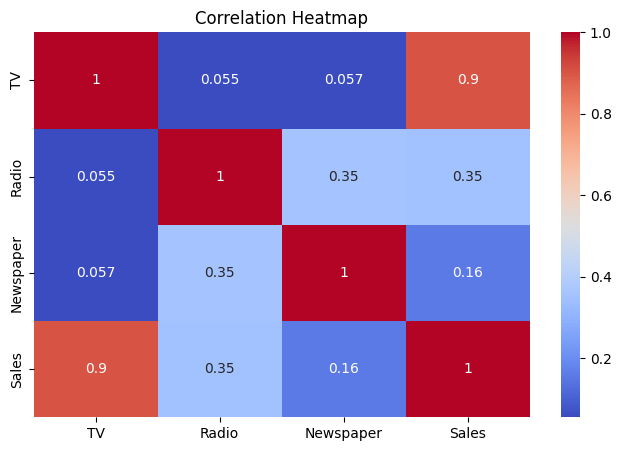

In [10]:
# 5. Correlation Heatmap

# Correlation between columns
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

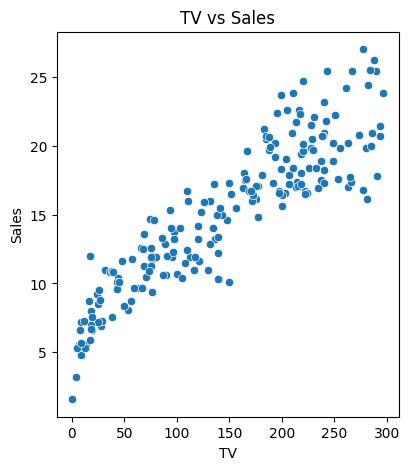

In [14]:
# 6. Feature vs Sales Graphs

# Plot relationships with Sales

#  6.1 TV vs Sales

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.title("TV vs Sales")

plt.show()

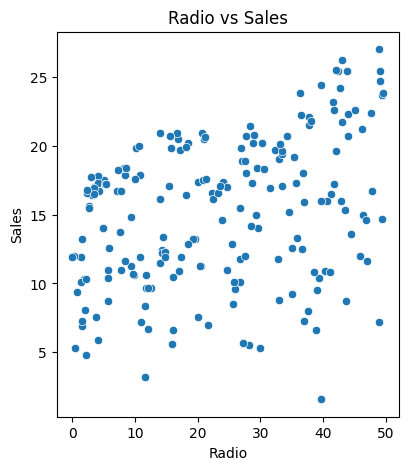

In [15]:
# Plot relationships with Sales

#  6.2 Radio vs Sales

plt.figure(figsize=(15,5))

plt.subplot(1,3,2)
sns.scatterplot(x=df["Radio"], y=df["Sales"])
plt.title("Radio vs Sales")

plt.show()

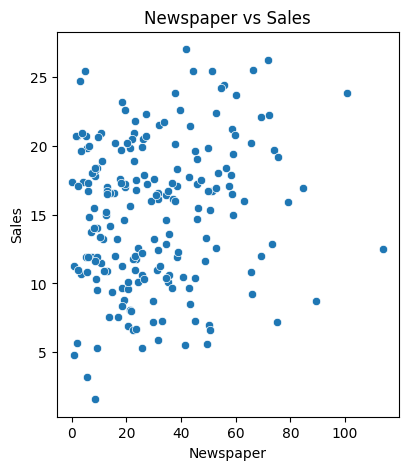

In [16]:
# Plot relationships with Sales

#  6.3 Newspaper vs Sales

plt.figure(figsize=(15,5))

plt.subplot(1,3,3)
sns.scatterplot(x=df["Newspaper"], y=df["Sales"])
plt.title("Newspaper vs Sales")

plt.show()

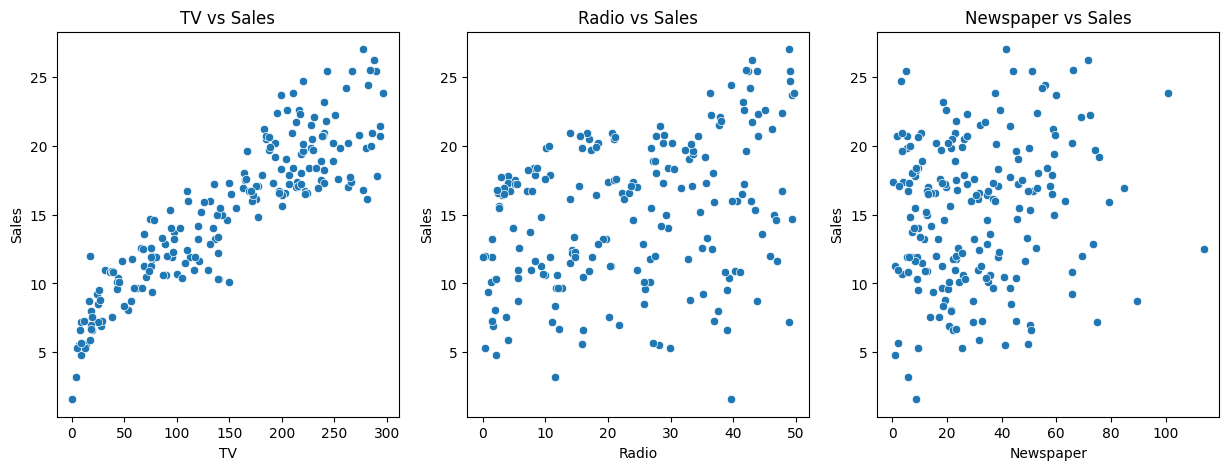

In [17]:
# Plot relationships with Sales

# Comparision of all 3 graphs

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.title("TV vs Sales")

plt.subplot(1,3,2)
sns.scatterplot(x=df["Radio"], y=df["Sales"])
plt.title("Radio vs Sales")

plt.subplot(1,3,3)
sns.scatterplot(x=df["Newspaper"], y=df["Sales"])
plt.title("Newspaper vs Sales")

plt.show()

In [18]:
# 7. Prepare Data for Machine Learning

# Split features and target

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 3)
Target shape: (200,)


In [19]:
# 8. Train Test Split

# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (160, 3)
X_test: (40, 3)
y_train: (160,)
y_test: (40,)


In [20]:
# 9. Create & Train Model

# Create Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

print("Model training completed successfully")

Model training completed successfully


In [21]:
# 10. Predict Sales

# Make predictions

y_pred = model.predict(X_test)

# Display predicted values

y_pred[:10]

array([17.0347724 , 20.40974033, 23.72398873,  9.27278518, 21.68271879,
       12.56940161, 21.08119452,  8.69035045, 17.23701254, 16.66657475])

In [22]:
# 11. Model Evaluation

# Model evaluation

#MAE → average prediction error
#MSE → error measurement
#R² Score → model accuracy (closer to 1 is better)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.2748262109549338
Mean Squared Error: 2.9077569102710896
R2 Score: 0.9059011844150826


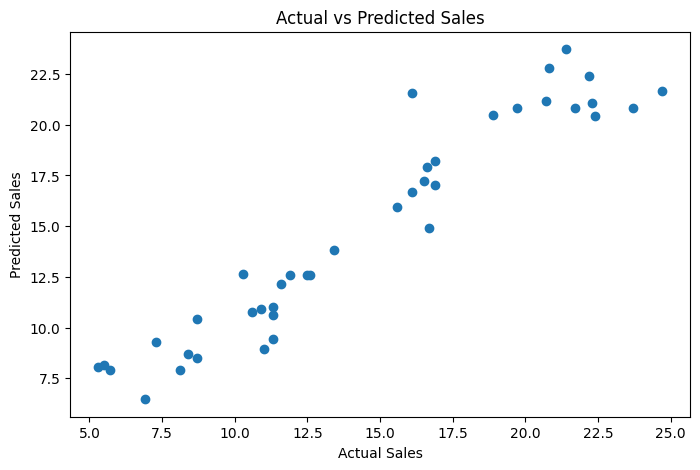

In [23]:
# 12. Actual vs Predicted Sales Graph

# Plot actual vs predicted sales

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [24]:
# 13. Feature Importance

# Feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


In [27]:
# 14. Actual & Predicted Sales Table

# Compare actual and predicted values

result = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

result.head(10)

,Actual Sales,Predicted Sales
0,16.9,17.034772
1,22.4,20.409740
2,21.4,23.723989
3,7.3,9.272785
4,24.7,21.682719
5,12.6,12.569402
6,22.3,21.081195
7,8.4,8.690350
8,16.5,17.237013
9,16.1,16.666575


In [28]:
# 15. Save the Model

import pickle

# Save trained model

with open("sales_prediction_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully
